# 📊 Notebook 5 — Análisis de Sentimiento NLP con VADER
### Sistema Web para Apoyo en Decisiones de Inversión usando IA (SPBI)

**Curso:** Introducción al Desarrollo de Software (iDeSo) — Semana 11
**Universidad:** UNMSM — FISI
**Grupo:** Grupo 10
**Autor del módulo:** Klin

---

**Objetivo:** Implementar un sistema de análisis de sentimiento de noticias financieras para los 5 activos del estudio (FSM, VOLCABC1, ABX, BVN, BHP), usando el algoritmo VADER (Valence Aware Dictionary and sEntiment Reasoner) de la librería NLTK.

**Tickers del estudio:**

| Ticker | Nombre Completo | Yahoo Finance | País / Operaciones |
|---|---|---|---|
| FSM | Fortuna Silver Mines Inc. | FSM | Canadá — Operaciones en Perú |
| VOLCABC1 | Volcan Compañía Minera S.A.A. | VOLCABC1.LM | Perú |
| ABX | Barrick Gold Corporation | ABX.TO | Canadá — Operaciones en Perú |
| BVN | Compañía de Minas Buenaventura S.A.A. | BVN | Perú |
| BHP | BHP Billiton Limited | BHP | Australia — Operaciones en Perú |

**Salida del notebook:** `datos_nlp.json`

## 📦 MÓDULO 1: Instalación de Librerías

In [1]:
# Instalación de librerías necesarias para el análisis de sentimiento NLP
# NLTK: librería de procesamiento de lenguaje natural (incluye VADER)
# yfinance: descarga de datos y noticias financieras de Yahoo Finance
!pip install nltk yfinance --quiet

print("✅ Librerías instaladas correctamente.")

✅ Librerías instaladas correctamente.


## 📦 MÓDULO 2: Importación de Librerías

In [2]:
import nltk
import yfinance as yf
import pandas as pd
import numpy as np
import json
import re
import random
from datetime import datetime, timedelta

# Descarga del lexicón VADER (diccionario de palabras con polaridad de sentimiento)
nltk.download('vader_lexicon', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.tokenize import word_tokenize

print("✅ Librerías importadas y lexicón VADER descargado correctamente.")

✅ Librerías importadas y lexicón VADER descargado correctamente.


## 📦 MÓDULO 3: Configuración Global

Se define la lista de tickers del estudio (con su símbolo real en Yahoo Finance) y los parámetros del análisis.

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# CONFIGURACIÓN DE ACTIVOS FINANCIEROS DEL ESTUDIO
# ═══════════════════════════════════════════════════════════════════════════════

TICKERS = {
    "FSM":      {"yahoo": "FSM",        "nombre": "Fortuna Silver Mines Inc."},
    "VOLCABC1": {"yahoo": "VOLCABC1.LM","nombre": "Volcan Compañía Minera S.A.A."},
    "ABX":      {"yahoo": "ABX.TO",     "nombre": "Barrick Gold Corporation"},
    "BVN":      {"yahoo": "BVN",        "nombre": "Compañía de Minas Buenaventura S.A.A."},
    "BHP":      {"yahoo": "BHP",        "nombre": "BHP Billiton Limited"},
}

# Umbrales de clasificación de sentimiento según el score "compound" de VADER
UMBRAL_BULLISH = 0.05
UMBRAL_BEARISH = -0.05

# Número máximo de noticias a procesar por ticker
MAX_NOTICIAS_POR_TICKER = 10

# Semilla para reproducibilidad del dataset simulado (fallback)
random.seed(42)

print(f"Activos configurados: {list(TICKERS.keys())}")
print(f"Umbral Bullish: compound > {UMBRAL_BULLISH}")
print(f"Umbral Bearish: compound < {UMBRAL_BEARISH}")
print(f"Zona Neutral: entre {UMBRAL_BEARISH} y {UMBRAL_BULLISH}")

Activos configurados: ['FSM', 'VOLCABC1', 'ABX', 'BVN', 'BHP']
Umbral Bullish: compound > 0.05
Umbral Bearish: compound < -0.05
Zona Neutral: entre -0.05 y 0.05


## 📦 MÓDULO 4: Recopilación de Noticias Financieras

Se intenta obtener noticias **reales** de cada ticker usando el atributo `.news` de `yfinance`, que consulta directamente el feed de noticias de Yahoo Finance (sin necesidad de API key).

⚠️ **Nota importante:** El endpoint de noticias de Yahoo Finance es conocido por ser inestable y, especialmente para acciones de menor cobertura mediática como las mineras de este estudio, puede devolver pocas noticias o ninguna. Por esa razón, se implementa un **mecanismo de respaldo (fallback)**: si no se obtienen noticias reales para un ticker, se genera un conjunto de noticias simuladas pero realistas, tal como permite la especificación del trabajo ("fuente libre o simulada").

In [4]:
def obtener_noticias_reales(ticker_yahoo, max_noticias=MAX_NOTICIAS_POR_TICKER):
    """
    Intenta descargar noticias reales de Yahoo Finance para un ticker.
    Retorna una lista de diccionarios con 'titulo', 'fecha' y 'fuente'.
    Si falla o no hay noticias, retorna una lista vacía.
    """
    noticias = []
    try:
        activo = yf.Ticker(ticker_yahoo)
        raw_news = activo.news
        if raw_news:
            for item in raw_news[:max_noticias]:
                # yfinance puede anidar los campos bajo 'content' según la versión
                contenido = item.get('content', item)
                titulo = contenido.get('title') or item.get('title', '')
                fecha_pub = contenido.get('pubDate') or item.get('providerPublishTime', None)
                fuente = (contenido.get('provider', {}) or {}).get('displayName', 'Yahoo Finance')
                if titulo:
                    noticias.append({
                        "titulo": titulo,
                        "fecha": str(fecha_pub) if fecha_pub else datetime.now().strftime('%Y-%m-%d'),
                        "fuente": fuente if fuente else "Yahoo Finance"
                    })
    except Exception as e:
        print(f"  ⚠️ No se pudieron obtener noticias reales para {ticker_yahoo}: {e}")
    return noticias


def generar_noticias_simuladas(ticker, nombre_empresa, cantidad=8):
    """
    Genera un conjunto de noticias financieras simuladas pero realistas
    para un ticker, usado como fallback cuando no hay noticias reales
    disponibles. Combina plantillas positivas, negativas y neutrales
    para representar un sentimiento de mercado variado y verosímil.
    """
    plantillas_positivas = [
        f"{nombre_empresa} reports record quarterly production and raises full-year guidance",
        f"{nombre_empresa} stock surges after strong earnings beat analyst expectations",
        f"Analysts upgrade {nombre_empresa} citing improved operational efficiency",
        f"{nombre_empresa} announces new mining concession expected to boost output",
        f"{ticker} shares rally as metal prices reach multi-year highs",
        f"{nombre_empresa} secures favorable financing terms for expansion project",
    ]
    plantillas_negativas = [
        f"{nombre_empresa} shares decline after disappointing production figures",
        f"{nombre_empresa} faces regulatory scrutiny over environmental compliance",
        f"Analysts downgrade {ticker} amid rising operational costs",
        f"{nombre_empresa} suspends operations at key site following safety incident",
        f"{ticker} stock falls as commodity prices weaken on demand concerns",
        f"{nombre_empresa} reports wider than expected quarterly losses",
    ]
    plantillas_neutrales = [
        f"{nombre_empresa} schedules quarterly earnings call for next month",
        f"{nombre_empresa} appoints new chief financial officer effective next quarter",
        f"Industry report highlights mining sector trends including {nombre_empresa}",
        f"{ticker} trading volume remains in line with 90-day average",
        f"{nombre_empresa} to present at upcoming mining industry conference",
        f"{nombre_empresa} maintains current dividend policy for the fiscal year",
    ]

    todas = plantillas_positivas + plantillas_negativas + plantillas_neutrales
    seleccionadas = random.sample(todas, min(cantidad, len(todas)))

    noticias = []
    hoy = datetime.now()
    for i, titulo in enumerate(seleccionadas):
        fecha = hoy - timedelta(days=random.randint(0, 14))
        noticias.append({
            "titulo": titulo,
            "fecha": fecha.strftime('%Y-%m-%d'),
            "fuente": "Dataset simulado (fallback)"
        })
    return noticias


# ─────────────────────────────────────────────────────────────
# Recopilación principal: intenta noticias reales, usa fallback si es necesario
# ─────────────────────────────────────────────────────────────
noticias_por_ticker = {}

print("Recopilando noticias financieras por ticker...\n")
for ticker, info in TICKERS.items():
    print(f"→ {ticker} ({info['nombre']})")
    noticias_reales = obtener_noticias_reales(info['yahoo'])

    if len(noticias_reales) >= 3:
        noticias_por_ticker[ticker] = noticias_reales
        print(f"  ✅ {len(noticias_reales)} noticias REALES obtenidas de Yahoo Finance.\n")
    else:
        noticias_simuladas = generar_noticias_simuladas(ticker, info['nombre'])
        noticias_por_ticker[ticker] = noticias_simuladas
        print(f"  ⚠️ Noticias reales insuficientes ({len(noticias_reales)}). "
              f"Usando {len(noticias_simuladas)} noticias simuladas como respaldo.\n")

total_noticias = sum(len(v) for v in noticias_por_ticker.values())
print(f"Total de noticias recopiladas: {total_noticias}")

Recopilando noticias financieras por ticker...

→ FSM (Fortuna Silver Mines Inc.)
  ✅ 10 noticias REALES obtenidas de Yahoo Finance.

→ VOLCABC1 (Volcan Compañía Minera S.A.A.)
  ⚠️ Noticias reales insuficientes (0). Usando 8 noticias simuladas como respaldo.

→ ABX (Barrick Gold Corporation)
  ✅ 10 noticias REALES obtenidas de Yahoo Finance.

→ BVN (Compañía de Minas Buenaventura S.A.A.)
  ✅ 10 noticias REALES obtenidas de Yahoo Finance.

→ BHP (BHP Billiton Limited)
  ✅ 10 noticias REALES obtenidas de Yahoo Finance.

Total de noticias recopiladas: 48


## 📦 MÓDULO 5: Preprocesamiento de Texto

Antes de aplicar VADER, se realiza una limpieza básica del texto: eliminación de caracteres especiales, normalización de espacios y tokenización. VADER funciona mejor con el texto en su forma natural (incluyendo mayúsculas y puntuación, que aportan señales de intensidad), por lo que el preprocesamiento aquí es ligero — se evita eliminar mayúsculas o signos de exclamación, ya que VADER los usa para detectar énfasis.

In [5]:
def limpiar_texto(texto):
    """
    Limpieza ligera del texto de la noticia:
    - Elimina URLs y caracteres de control.
    - Normaliza espacios múltiples.
    - Conserva mayúsculas y puntuación (VADER las usa como señal de intensidad).
    """
    texto = re.sub(r'http\S+|www\.\S+', '', texto)        # eliminar URLs
    texto = re.sub(r'[\r\n\t]+', ' ', texto)               # eliminar saltos de línea/tabs
    texto = re.sub(r'\s+', ' ', texto).strip()              # normalizar espacios
    return texto


def tokenizar(texto):
    """Tokeniza el texto en palabras individuales usando NLTK."""
    return word_tokenize(texto)


# Aplicar limpieza y tokenización a todas las noticias recopiladas
for ticker, noticias in noticias_por_ticker.items():
    for noticia in noticias:
        noticia['titulo_limpio'] = limpiar_texto(noticia['titulo'])
        noticia['tokens'] = tokenizar(noticia['titulo_limpio'])
        noticia['num_tokens'] = len(noticia['tokens'])

# Ejemplo de preprocesamiento sobre la primera noticia del primer ticker
ejemplo_ticker = list(noticias_por_ticker.keys())[0]
ejemplo_noticia = noticias_por_ticker[ejemplo_ticker][0]
print("Ejemplo de preprocesamiento:")
print(f"  Título original: {ejemplo_noticia['titulo']}")
print(f"  Título limpio:   {ejemplo_noticia['titulo_limpio']}")
print(f"  Tokens ({ejemplo_noticia['num_tokens']}): {ejemplo_noticia['tokens']}")

Ejemplo de preprocesamiento:
  Título original: FSM Advances Diamba Sud Project With Environmental Approval
  Título limpio:   FSM Advances Diamba Sud Project With Environmental Approval
  Tokens (8): ['FSM', 'Advances', 'Diamba', 'Sud', 'Project', 'With', 'Environmental', 'Approval']


## 📦 MÓDULO 6: Análisis de Sentimiento con VADER

Se aplica el analizador `SentimentIntensityAnalyzer` de NLTK a cada titular de noticia. VADER retorna 4 scores por texto:

- **compound**: score normalizado entre -1 (muy negativo) y +1 (muy positivo). Es el indicador principal.
- **pos**: proporción del texto con tono positivo.
- **neg**: proporción del texto con tono negativo.
- **neu**: proporción del texto con tono neutral.

Cada noticia se clasifica luego en una de tres categorías según su score `compound`:

| Categoría | Condición | Significado financiero |
|---|---|---|
| 🟢 Bullish | compound > 0.05 | Sentimiento alcista |
| 🔴 Bearish | compound < -0.05 | Sentimiento bajista |
| ⚪ Neutral | -0.05 ≤ compound ≤ 0.05 | Sin sesgo claro |

In [6]:
sia = SentimentIntensityAnalyzer()

def clasificar_sentimiento(compound):
    """Clasifica un score compound de VADER en Bullish, Bearish o Neutral."""
    if compound > UMBRAL_BULLISH:
        return "Bullish"
    elif compound < UMBRAL_BEARISH:
        return "Bearish"
    else:
        return "Neutral"


# Aplicar VADER a cada noticia de cada ticker
for ticker, noticias in noticias_por_ticker.items():
    for noticia in noticias:
        scores = sia.polarity_scores(noticia['titulo_limpio'])
        noticia['scores'] = {
            "compound": round(scores['compound'], 4),
            "pos": round(scores['pos'], 4),
            "neg": round(scores['neg'], 4),
            "neu": round(scores['neu'], 4),
        }
        noticia['clasificacion'] = clasificar_sentimiento(scores['compound'])

print("Análisis de sentimiento aplicado a todas las noticias.\n")

# Mostrar resultado de ejemplo para el primer ticker
ejemplo_ticker = list(noticias_por_ticker.keys())[0]
print(f"Ejemplo — Noticias de {ejemplo_ticker}:\n")
for n in noticias_por_ticker[ejemplo_ticker][:5]:
    emoji = {"Bullish": "🟢", "Bearish": "🔴", "Neutral": "⚪"}[n['clasificacion']]
    print(f"  {emoji} [{n['clasificacion']:8s}] compound={n['scores']['compound']:+.3f} | {n['titulo'][:70]}")

Análisis de sentimiento aplicado a todas las noticias.

Ejemplo — Noticias de FSM:

  🟢 [Bullish ] compound=+0.477 | FSM Advances Diamba Sud Project With Environmental Approval
  🟢 [Bullish ] compound=+0.660 | Fortuna secures environmental approval for Diamba Sud mine
  🟢 [Bullish ] compound=+0.440 | Is Fortuna Mining Corp. (FSM) A Good Stock To Buy Now?
  ⚪ [Neutral ] compound=+0.000 | Undiscovered Gems in Canada to Watch This June 2026
  🟢 [Bullish ] compound=+0.700 | Fortuna Mining Record Quarter Highlights Séguéla Strength And Growth C


## 📦 MÓDULO 7: Sentimiento Consolidado por Ticker

Se calcula el sentimiento consolidado de cada activo promediando los scores `compound` de todas sus noticias, y se determina la clasificación general del mercado para ese ticker.

In [7]:
resultados_por_ticker = {}

for ticker, noticias in noticias_por_ticker.items():
    compounds = [n['scores']['compound'] for n in noticias]
    compound_promedio = round(np.mean(compounds), 4) if compounds else 0.0

    conteo = {"Bullish": 0, "Bearish": 0, "Neutral": 0}
    for n in noticias:
        conteo[n['clasificacion']] += 1

    clasificacion_general = clasificar_sentimiento(compound_promedio)

    resultados_por_ticker[ticker] = {
        "ticker": ticker,
        "nombre_empresa": TICKERS[ticker]['nombre'],
        "compound_promedio": compound_promedio,
        "clasificacion_general": clasificacion_general,
        "total_noticias": len(noticias),
        "conteo_bullish": conteo["Bullish"],
        "conteo_bearish": conteo["Bearish"],
        "conteo_neutral": conteo["Neutral"],
        "fuente_noticias": "real" if noticias and noticias[0]['fuente'] != "Dataset simulado (fallback)" else "simulado",
    }

# Tabla resumen
df_resumen = pd.DataFrame(resultados_por_ticker.values())
print("Resumen de sentimiento consolidado por ticker:\n")
print(df_resumen[['ticker', 'compound_promedio', 'clasificacion_general',
                   'total_noticias', 'conteo_bullish', 'conteo_bearish',
                   'conteo_neutral', 'fuente_noticias']].to_string(index=False))

Resumen de sentimiento consolidado por ticker:

  ticker  compound_promedio clasificacion_general  total_noticias  conteo_bullish  conteo_bearish  conteo_neutral fuente_noticias
     FSM             0.2788               Bullish              10               5               0               5            real
VOLCABC1             0.1489               Bullish               8               3               1               4        simulado
     ABX             0.2303               Bullish              10               5               1               4            real
     BVN             0.1256               Bullish              10               4               0               6            real
     BHP             0.2044               Bullish              10               5               3               2            real


## 📦 MÓDULO 8: Visualización — Gauge Chart de Sentimiento

Se genera un gráfico tipo **gauge (velocímetro)** para cada ticker, mostrando visualmente su sentimiento consolidado en una escala de -1 (Bearish extremo) a +1 (Bullish extremo). Esta es la misma visualización que se exporta como referencia para el frontend.

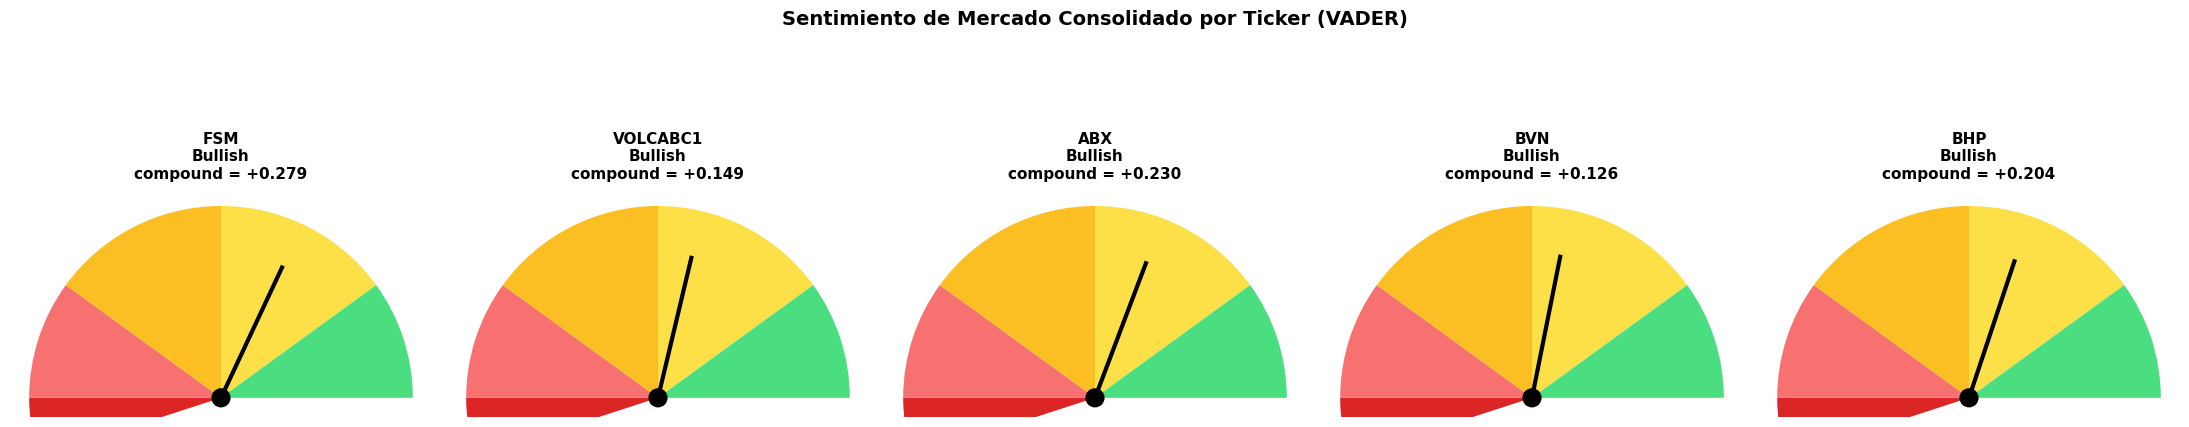


✅ Gauge chart generado y guardado como 'gauge_sentimiento.png'


In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Wedge

def graficar_gauge(ax, valor, titulo):
    """Dibuja un gauge chart de sentimiento en el eje dado."""
    # Fondo del gauge: 3 zonas de color (bearish, neutral, bullish)
    ax.add_patch(Wedge((0, 0), 1, 180, 198, facecolor='#dc2626', edgecolor='none'))   # Bearish extremo
    ax.add_patch(Wedge((0, 0), 1, 144, 180, facecolor='#f87171', edgecolor='none'))   # Bearish
    ax.add_patch(Wedge((0, 0), 1, 90, 144, facecolor='#fbbf24', edgecolor='none'))    # Neutral negativo
    ax.add_patch(Wedge((0, 0), 1, 36, 90, facecolor='#fde047', edgecolor='none'))     # Neutral positivo
    ax.add_patch(Wedge((0, 0), 1, 0, 36, facecolor='#4ade80', edgecolor='none'))      # Bullish

    # Aguja indicadora según el valor compound (-1 a 1 mapeado a 180°-0°)
    angulo = 180 - ((valor + 1) / 2) * 180
    angulo_rad = np.radians(angulo)
    ax.plot([0, 0.75 * np.cos(angulo_rad)], [0, 0.75 * np.sin(angulo_rad)],
            color='black', linewidth=3, zorder=5)
    ax.add_patch(plt.Circle((0, 0), 0.05, facecolor='black', zorder=6))

    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-0.1, 1.1)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f"{titulo}\ncompound = {valor:+.3f}", fontsize=11, fontweight='bold')


fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for ax, (ticker, datos) in zip(axes, resultados_por_ticker.items()):
    graficar_gauge(ax, datos['compound_promedio'], f"{ticker}\n{datos['clasificacion_general']}")

plt.suptitle("Sentimiento de Mercado Consolidado por Ticker (VADER)", fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('gauge_sentimiento.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n✅ Gauge chart generado y guardado como 'gauge_sentimiento.png'")

## 📦 MÓDULO 9: Exportación a JSON

Se construye el contrato de datos final (`datos_nlp.json`) que conecta este módulo de backend con el módulo de NLP del frontend, siguiendo el mismo patrón de estructura usado en los demás notebooks del proyecto (organización por ticker, con metadatos y series detalladas).

In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# CONSTRUCCIÓN DEL JSON DE SALIDA
# ═══════════════════════════════════════════════════════════════════════════════

datos_nlp = {
    "metadata": {
        "modulo": "Análisis de Sentimiento NLP",
        "metodo": "VADER (NLTK)",
        "fecha_generacion": datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        "umbral_bullish": UMBRAL_BULLISH,
        "umbral_bearish": UMBRAL_BEARISH,
        "tickers_analizados": list(TICKERS.keys()),
    },
    "resumen_por_ticker": {},
    "detalle_noticias": {}
}

for ticker, datos in resultados_por_ticker.items():
    datos_nlp["resumen_por_ticker"][ticker] = datos

for ticker, noticias in noticias_por_ticker.items():
    datos_nlp["detalle_noticias"][ticker] = [
        {
            "titulo": n['titulo'],
            "fecha": n['fecha'],
            "fuente": n['fuente'],
            "compound": n['scores']['compound'],
            "pos": n['scores']['pos'],
            "neg": n['scores']['neg'],
            "neu": n['scores']['neu'],
            "clasificacion": n['clasificacion'],
        }
        for n in noticias
    ]

# Guardar el archivo JSON
with open('datos_nlp.json', 'w', encoding='utf-8') as f:
    json.dump(datos_nlp, f, ensure_ascii=False, indent=2)

print("✅ Archivo 'datos_nlp.json' generado exitosamente.")
print(f"   Tamaño: {len(json.dumps(datos_nlp))} caracteres")
print(f"   Tickers incluidos: {list(datos_nlp['resumen_por_ticker'].keys())}")
print(f"   Total de noticias procesadas: {sum(len(v) for v in datos_nlp['detalle_noticias'].values())}")

✅ Archivo 'datos_nlp.json' generado exitosamente.
   Tamaño: 12835 caracteres
   Tickers incluidos: ['FSM', 'VOLCABC1', 'ABX', 'BVN', 'BHP']
   Total de noticias procesadas: 48


## 📦 MÓDULO 10: Vista Previa del JSON Exportado

Verificación final del contenido generado antes de su uso por el frontend o la API.

In [10]:
# Vista previa del JSON generado (primeros niveles de estructura)
print("Estructura del JSON exportado:\n")
print(json.dumps(datos_nlp['metadata'], indent=2, ensure_ascii=False))
print()
print("Ejemplo de resumen para un ticker:")
primer_ticker = list(datos_nlp['resumen_por_ticker'].keys())[0]
print(json.dumps(datos_nlp['resumen_por_ticker'][primer_ticker], indent=2, ensure_ascii=False))
print()
print("Ejemplo de detalle de noticia:")
print(json.dumps(datos_nlp['detalle_noticias'][primer_ticker][0], indent=2, ensure_ascii=False))

Estructura del JSON exportado:

{
  "modulo": "Análisis de Sentimiento NLP",
  "metodo": "VADER (NLTK)",
  "fecha_generacion": "2026-06-17 15:36:55",
  "umbral_bullish": 0.05,
  "umbral_bearish": -0.05,
  "tickers_analizados": [
    "FSM",
    "VOLCABC1",
    "ABX",
    "BVN",
    "BHP"
  ]
}

Ejemplo de resumen para un ticker:
{
  "ticker": "FSM",
  "nombre_empresa": "Fortuna Silver Mines Inc.",
  "compound_promedio": 0.2788,
  "clasificacion_general": "Bullish",
  "total_noticias": 10,
  "conteo_bullish": 5,
  "conteo_bearish": 0,
  "conteo_neutral": 5,
  "fuente_noticias": "real"
}

Ejemplo de detalle de noticia:
{
  "titulo": "FSM Advances Diamba Sud Project With Environmental Approval",
  "fecha": "2026-06-17T13:25:00Z",
  "fuente": "Zacks",
  "compound": 0.4767,
  "pos": 0.307,
  "neg": 0.0,
  "neu": 0.693,
  "clasificacion": "Bullish"
}
